In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df_min = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/min_energy_results.csv")

In [3]:
animal_ids = [0, 103, 169, 206, 
              124, 22, 116, 187, 
              14, 193]

df_my_animals_min = df_min[df_min["subj_index"].isin(animal_ids)]
df_animal_names = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed.csv")
# df_animal_names[df_animal_names["Unnamed: 0"].isin([0, 103, 169, 206])]

df_merged = pd.merge(df_my_animals_min, df_animal_names, left_on="subj_index", right_on="Unnamed: 0")
df_merged

,subj_index,gamma,eta,energy,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0,0.168562,2.668896,0.131313,0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,14,0.882274,-5.020067,0.082828,14,CapraNubiana1,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
2,22,0.841806,-4.725752,0.080000,22,GreenMonkey1,African green monkey (grivet),Green Monkey,Chlorocebus sabaeus,Chlorocebus,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,66.0,63.70,Literature
3,103,0.238462,-5.093646,0.080000,103,Orangutan2,Sumatran Orangutan,Orangutan,Pongo borneo,Pongo,Ponginae,Hominidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
4,116,0.617391,-4.983277,0.100000,116,Goat2,Domestic goat,Goat,Capra aegagrus hircus,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,115.0,111.00,Literature
5,124,0.507023,-4.983277,0.120000,124,WildBoar2,Wild boar,Wild Boar,Sus Scrofa,Sus,Suinae,Suidae,Suina,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
6,169,0.161204,-1.745819,0.080000,169,RedKangaroo3,Red Kangaroo,Red Kangaroo,Macropus rufus,Macropus,Macropodinae,Macropodidae,MacropodiformesPotoroidae,Marsupialia,No placenta,Other,56.0,54.10,Literature
7,187,0.558528,-4.836121,0.100000,187,FallowDeer1,Fallow deer,Fallow Deer,Dama Dama,Dama,Cervinae,Cervidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
8,193,0.679933,-4.946488,0.080000,193,Tiger,Bengal Tiger,Tiger,NaN,NaN,NaN,Felidae,NaN,Carnivora,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
9,206,0.223746,-5.056856,0.070000,206,Chimpanzee,Chimpanzee,Chimpanzee,Pan troglodytes (Chimpanzee),Pan,Homininae,Hominidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN


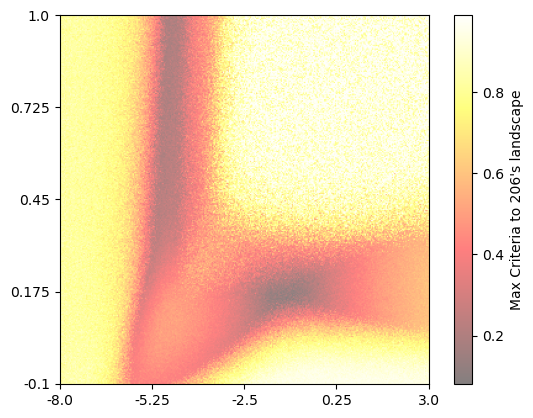

In [4]:
df_energy_landscape = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/all_metrics_for_76_90000_samples_animal_206.csv")
energy_landscape = df_energy_landscape.pivot(index='gamma', columns='eta', values='MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)')
# flip by diagonal
energy_landscape = energy_landscape.to_numpy()[::-1, :] # [:, ::-1].T # , :] # , ::-1]

# rescale axis
plt.xticks(ticks=np.linspace(0, energy_landscape.shape[1]-1, num=5), labels=np.round(np.linspace(-8, 3, num=5), 3))
plt.yticks(ticks=np.linspace(0, energy_landscape.shape[0]-1, num=5), labels=np.round(np.linspace(1, -0.1, num=5), 3))

plt.imshow(energy_landscape, cmap="hot", aspect="equal", alpha=0.5)
plt.colorbar(label="Max Criteria to 206's landscape")

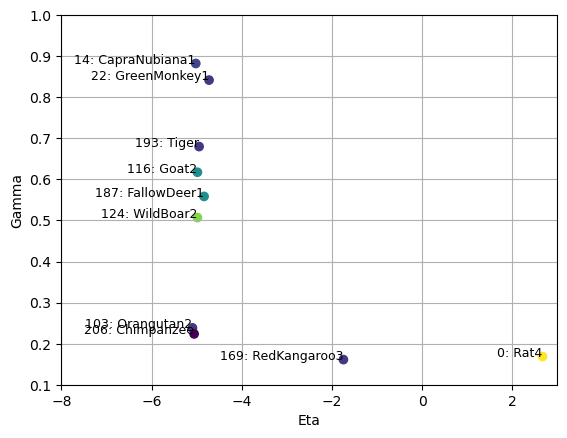

In [5]:
plt.scatter(df_merged["eta"], df_merged["gamma"], c=df_merged["energy"])
# add subj_index as text labels
for i, row in df_merged.iterrows():
    plt.text(row["eta"], row["gamma"], f"{int(row['subj_index'])}: {row['animal']}", fontsize=9, ha='right')

plt.xlabel("Eta")
plt.ylabel("Gamma")
plt.grid(True)
plt.xlim([-8,3])
plt.ylim([0.1, 1])
# plt.colorbar(label='Energy (of 206's landscape)')
plt.show()

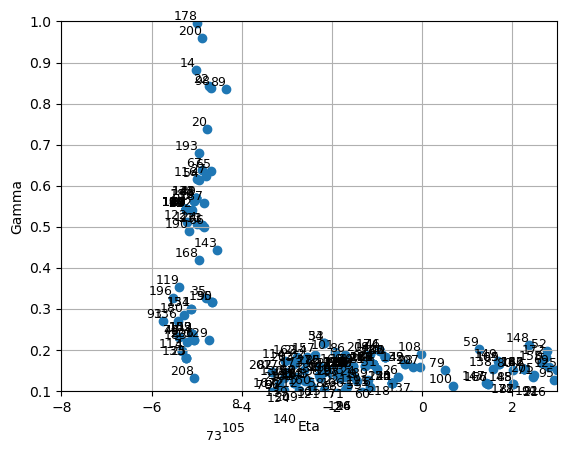

In [6]:
plt.scatter(df_min["eta"], df_min["gamma"])
# add subj_index as text labels. Make sure they dont overlap too much.
for i, row in df_min.iterrows():
    plt.text(row["eta"], row["gamma"], str(int(row["subj_index"])), fontsize=9, ha='right', va='bottom')

plt.xlabel("Eta")
plt.ylabel("Gamma")
plt.grid(True)
plt.xlim([-8,3])
plt.ylim([0.1, 1])
plt.show()

In [7]:
df_animal_names = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed.csv")
# df_animal_names[df_animal_names["Unnamed: 0"].isin([0, 103, 169, 206])]

pd.merge(df_my_animals_min, df_animal_names, left_on="subj_index", right_on="Unnamed: 0")

,subj_index,gamma,eta,energy,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0,0.168562,2.668896,0.131313,0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,14,0.882274,-5.020067,0.082828,14,CapraNubiana1,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
2,22,0.841806,-4.725752,0.080000,22,GreenMonkey1,African green monkey (grivet),Green Monkey,Chlorocebus sabaeus,Chlorocebus,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,66.0,63.70,Literature
3,103,0.238462,-5.093646,0.080000,103,Orangutan2,Sumatran Orangutan,Orangutan,Pongo borneo,Pongo,Ponginae,Hominidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
4,116,0.617391,-4.983277,0.100000,116,Goat2,Domestic goat,Goat,Capra aegagrus hircus,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,115.0,111.00,Literature
5,124,0.507023,-4.983277,0.120000,124,WildBoar2,Wild boar,Wild Boar,Sus Scrofa,Sus,Suinae,Suidae,Suina,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
6,169,0.161204,-1.745819,0.080000,169,RedKangaroo3,Red Kangaroo,Red Kangaroo,Macropus rufus,Macropus,Macropodinae,Macropodidae,MacropodiformesPotoroidae,Marsupialia,No placenta,Other,56.0,54.10,Literature
7,187,0.558528,-4.836121,0.100000,187,FallowDeer1,Fallow deer,Fallow Deer,Dama Dama,Dama,Cervinae,Cervidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
8,193,0.679933,-4.946488,0.080000,193,Tiger,Bengal Tiger,Tiger,NaN,NaN,NaN,Felidae,NaN,Carnivora,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
9,206,0.223746,-5.056856,0.070000,206,Chimpanzee,Chimpanzee,Chimpanzee,Pan troglodytes (Chimpanzee),Pan,Homininae,Hominidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN


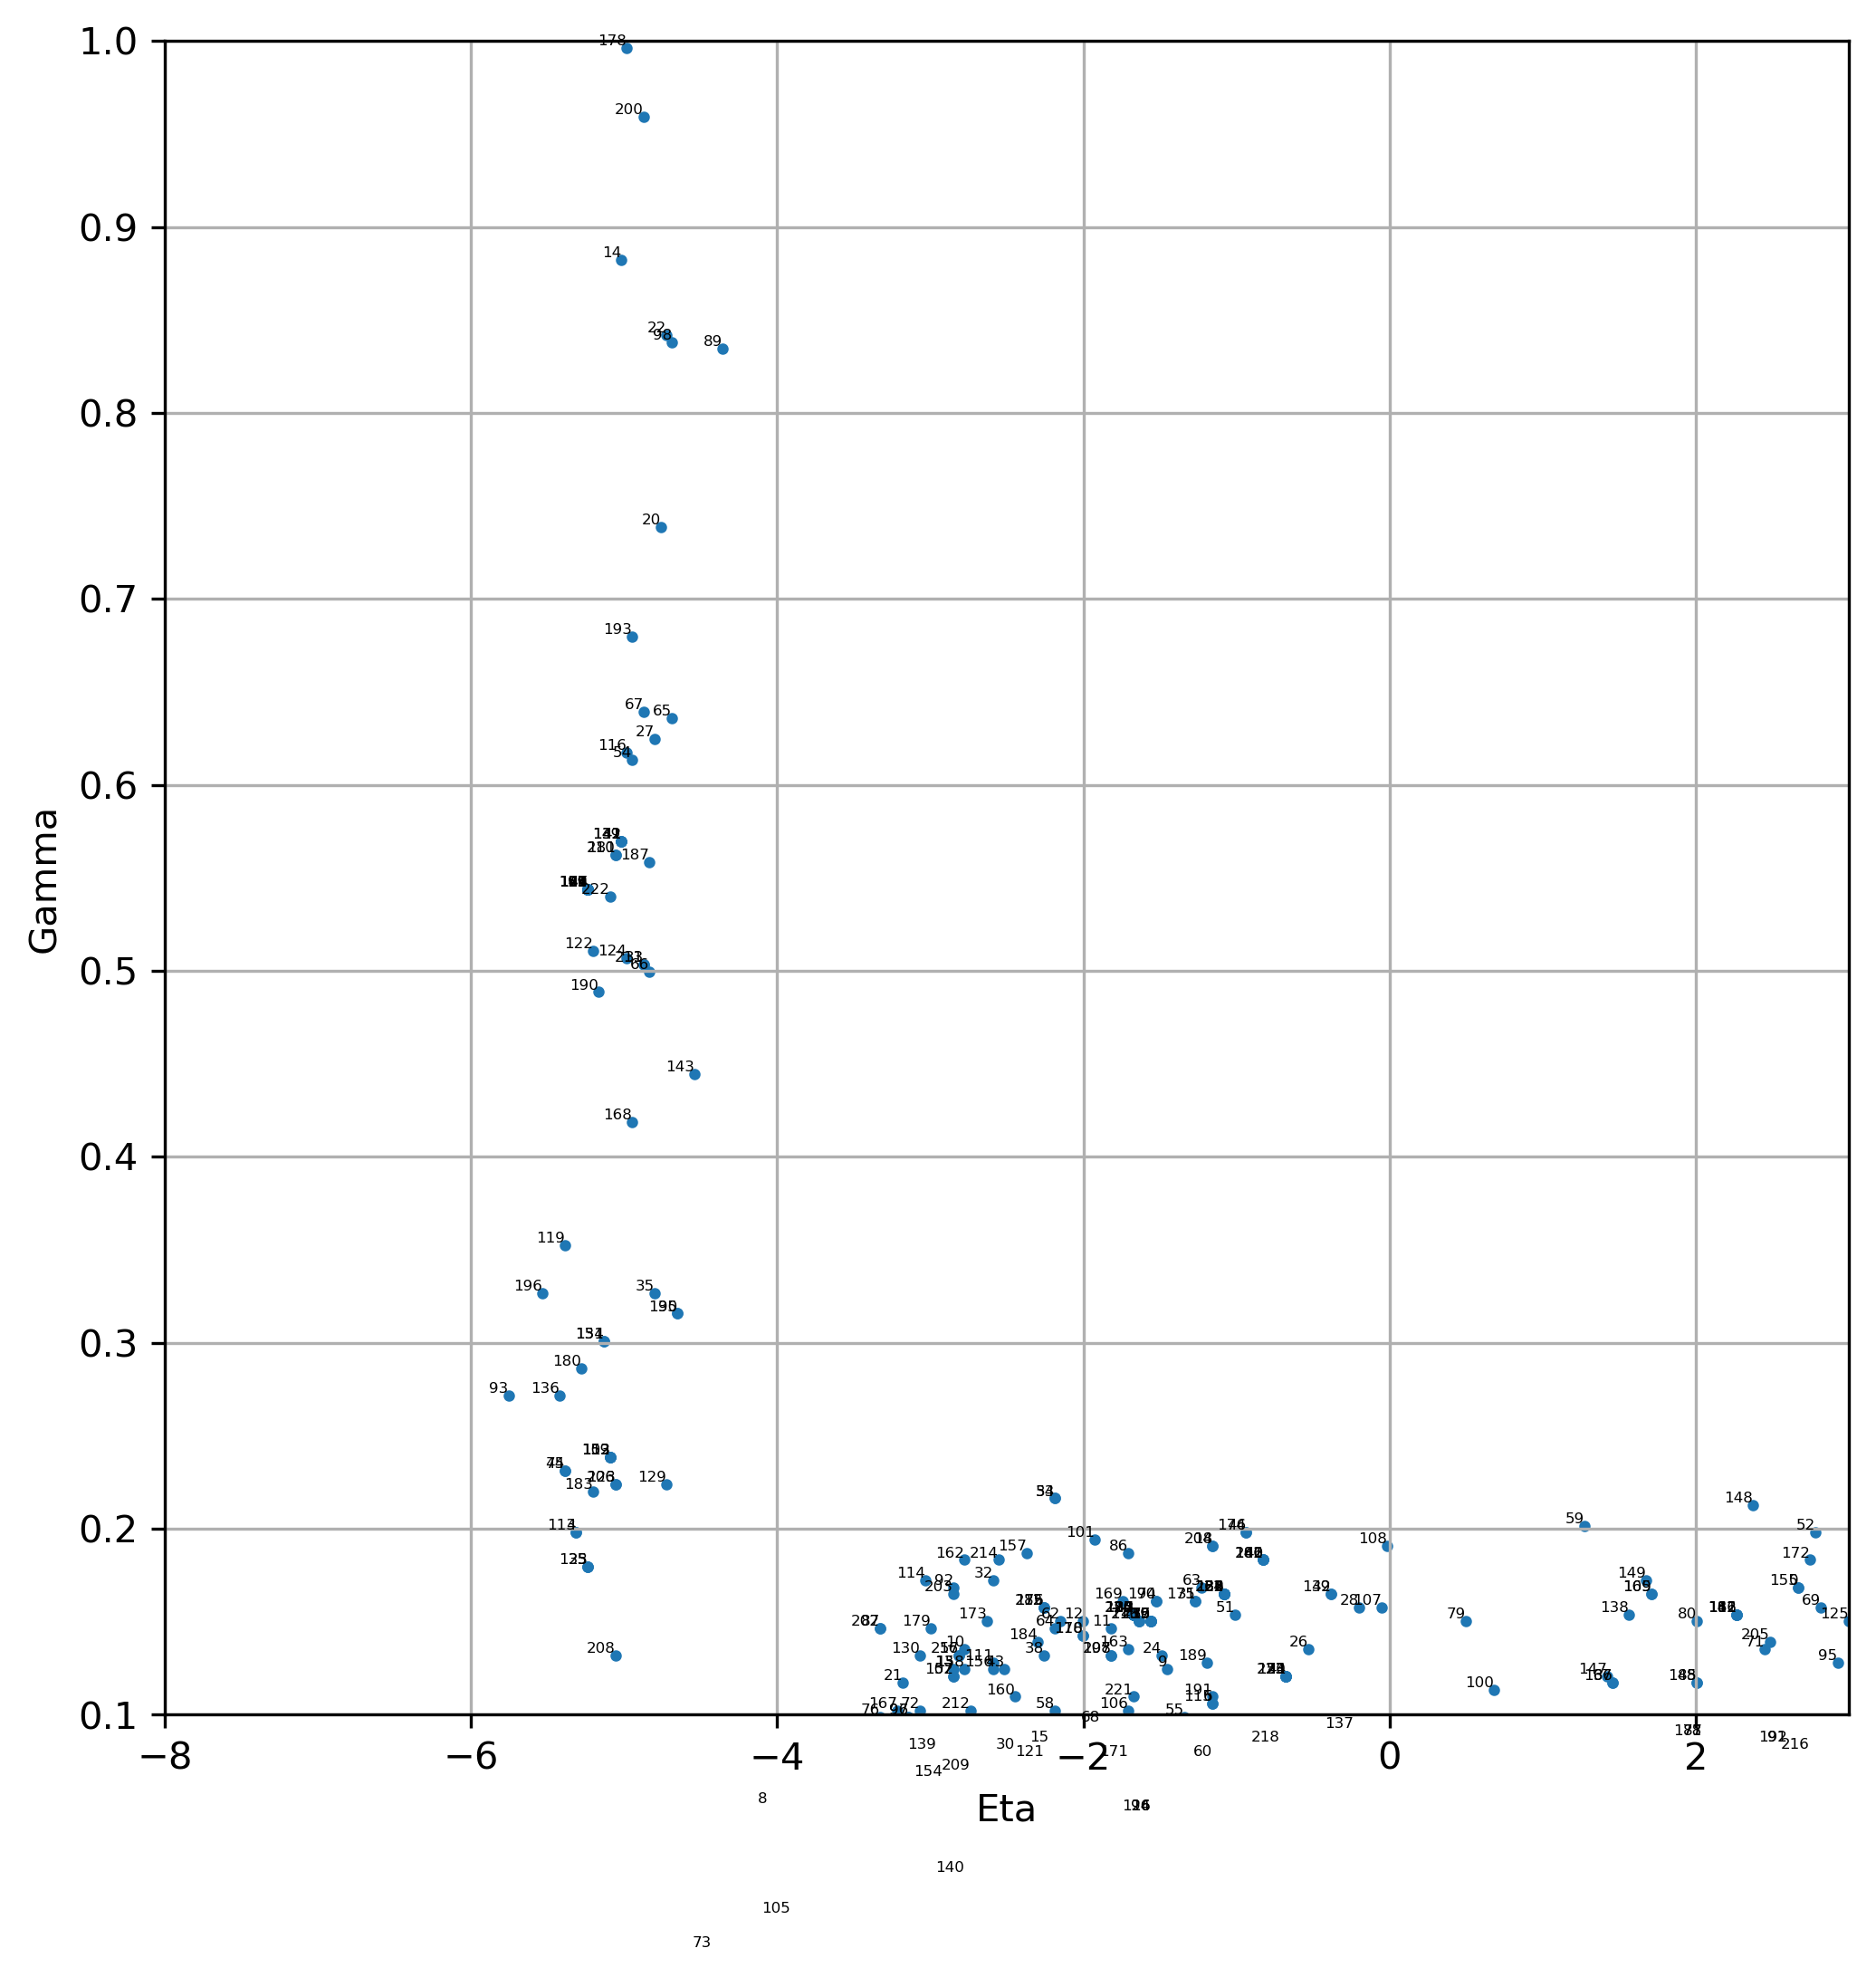

In [8]:
plt.figure(figsize=(8,8), dpi=300) 
plt.scatter(df_min["eta"], df_min["gamma"], s=4)
# add subj_index as text labels. Make sure they dont overlap too much.
for i, row in df_min.iterrows():
    plt.text(row["eta"], row["gamma"], str(int(row["subj_index"])), fontsize=4, ha='right', va='bottom')

plt.xlabel("Eta")
plt.ylabel("Gamma")
plt.grid(True)
plt.xlim([-8,3])
plt.ylim([0.1, 1])
plt.show()